# Loading Data & Visualization 

In [24]:
# Import the needed libraries
import numpy as np 
import pandas as pd 
import yfinance as yf
# Setting Plotly backend plotting for pandas 
pd.options.plotting.backend = 'plotly'
import plotly.io as pio
pio.templates.default = 'plotly_dark'

In [2]:
# import raw data from yfinance
raw = yf.download('^GSPC', start='2000-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
# check our loaded data 
raw

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000
...,...,...,...,...,...
2026-04-27,7173.910156,7178.740234,7146.720215,7152.720215,4783750000
2026-04-28,7138.799805,7152.520020,7115.169922,7133.740234,4900650000



Every observation is a trading day, The market starts trading at 9:30 AM that's the first price at which the index trades,
during the trading day the price changes, the Highest price in the same session is the High, and the Lowest price is the low,
the trading day finishes at 4:00 PM That would be the Close price, The amount of shares traded during a given day is the Volume.

Close Price is meaningful as it shows how the market agrees on pricing a specific stock after the day trading is finished and for analysis and model training.
Volume is important for understanding if the price change is meaningful or noise.

## Data Inspection 

In [4]:
# Check the DataSet shape
raw.shape

(6622, 5)

In [5]:
type(raw.index)

pandas.DatetimeIndex

In [6]:
# Check for missing values 
raw.isnull().sum()

Price   Ticker
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Volume  ^GSPC     0
dtype: int64

In [7]:
# Check Data description 
raw.describe()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
count,6622.000000,6622.000000,6622.000000,6622.000000,6.622000e+03
mean,2326.481866,2339.323639,2311.878902,2326.105947,3.445198e+09
std,1532.727423,1539.437119,1524.730083,1532.345076,1.525509e+09
min,676.530029,695.270020,666.789978,679.280029,0.000000e+00
25%,1213.472473,1220.190033,1205.379974,1213.057526,2.339380e+09
50%,1551.849976,1556.330017,1543.764954,1551.419983,3.543750e+09
75%,2931.725037,2943.812500,2917.822449,2930.184998,4.290578e+09
max,7230.120117,7272.520020,7229.319824,7234.540039,1.145623e+10


## The Minimum value of the volume is 0, which shouldn't be the case, we inspect that further

In [8]:
# Flatten multi-level columns
raw.columns = raw.columns.get_level_values(0)
raw.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


In [9]:
# How many days have a volume of 0
raw[raw['Volume'] == 0]

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-05-24,4115.240234,4132.959961,4103.97998,4132.959961,0


### The day 24th of May 2023 is a normal trading day, it might be something wrong on yfinance data, 
### We drop the row for that day

### When inspecting the Volume for last day it was relatively low, the reason I found is the trading day has NOT finished yet
### or yfinance didn't didn't update the last trading day
### for forecasting purposes, an incomplete trading day can skew my most recent data point.

In [10]:
# We drop the rows that has Zero volume by 
raw = raw[raw['Volume']  > 0]

In [11]:
# Confirm no zero-volume rows remain
raw[raw['Volume'] == 0]

Price,Close,High,Low,Open,Volume
Date,,,,,


In [12]:
# Drop the most recent trading day as it may be incomplete
# This ensures model accuracy is not affected by partial data at any point in time
raw = raw.iloc[:-1]

In [13]:
# Confirm the last row
raw.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-04-24,7165.080078,7168.589844,7112.819824,7136.479980,4608830000
2026-04-27,7173.910156,7178.740234,7146.720215,7152.720215,4783750000
2026-04-28,7138.799805,7152.520020,7115.169922,7133.740234,4900650000
2026-04-29,7135.950195,7145.629883,7107.859863,7131.609863,5123100000
2026-04-30,7209.009766,7219.830078,7126.149902,7161.750000,5723790000


In [14]:
# We create a new column and calculate the daily log Returns

raw['log_returns'] = np.log(raw['Close']/ raw['Close'].shift(1))



In [15]:
# Double check our results

raw[['Close', 'log_returns']].head(10)

Price,Close,log_returns
Date,,
2000-01-03,1455.219971,NaN
2000-01-04,1399.420044,-0.039099
2000-01-05,1402.109985,0.001920
2000-01-06,1403.449951,0.000955
2000-01-07,1441.469971,0.026730
2000-01-10,1457.599976,0.011128
2000-01-11,1438.560059,-0.013149
2000-01-12,1432.250000,-0.004396
2000-01-13,1449.680054,0.012096


We used Log daily returns to stablize the variance through our data, which is a core assumption for stationarity assumption
for applying our statsitical models(ARIMA, SARIMA, PROPHET)
And the log return has a property called time additive, the additivity makes log returns much easier to work mathmetically, 
which is the standard in quantitive finance

In [16]:
# I drop the first row as we can't compute daily returns for the first day of our data 
raw = raw.dropna(subset=['log_returns'])

# To confirm that all NaN values dropped:
raw['log_returns'].isna().sum()

np.int64(0)

In [17]:
# We inspect the log_returns column
raw['log_returns'].describe()

count    6619.000000
mean        0.000242
std         0.012180
min        -0.127652
25%        -0.004735
50%         0.000637
75%         0.005878
max         0.109572
Name: log_returns, dtype: float64

The mean of the log_returns is almost zero, which satisfy the stationarity part of the data
Std (Standard Deviation):  this is average daily volatility, about 1.2% per day


In [18]:
# We check the min and max dates for the daily returns :
# Find the actual dates of extreme moves
raw['log_returns'].nsmallest(5)

Date
2020-03-16   -0.127652
2020-03-12   -0.099945
2008-10-15   -0.094695
2008-12-01   -0.093537
2008-09-29   -0.092190
Name: log_returns, dtype: float64

In [19]:
raw['log_returns'].nlargest(5)

Date
2008-10-13    0.109572
2008-10-28    0.102457
2025-04-09    0.090895
2020-03-24    0.089683
2020-03-13    0.088808
Name: log_returns, dtype: float64

The largest single-day gains:

2008 dominates the top gains — October 13 and 28, 2008 were both massive bailout-driven relief rallies during the financial crisis
April 9, 2025 — that's your Trump tariff pause
March 2020 — two entries, both COVID-era "dead cat bounces" as markets briefly rebounded during the crash

The largest single-day losses:

March 16, 2020 — the worst day in entire dataset at -12.7%, the Monday after the first COVID lockdown weekend
March 12, 2020 — two days earlier, WHO officially declared a pandemic
The rest are all 2008 — September through December, the heart of the financial crisis

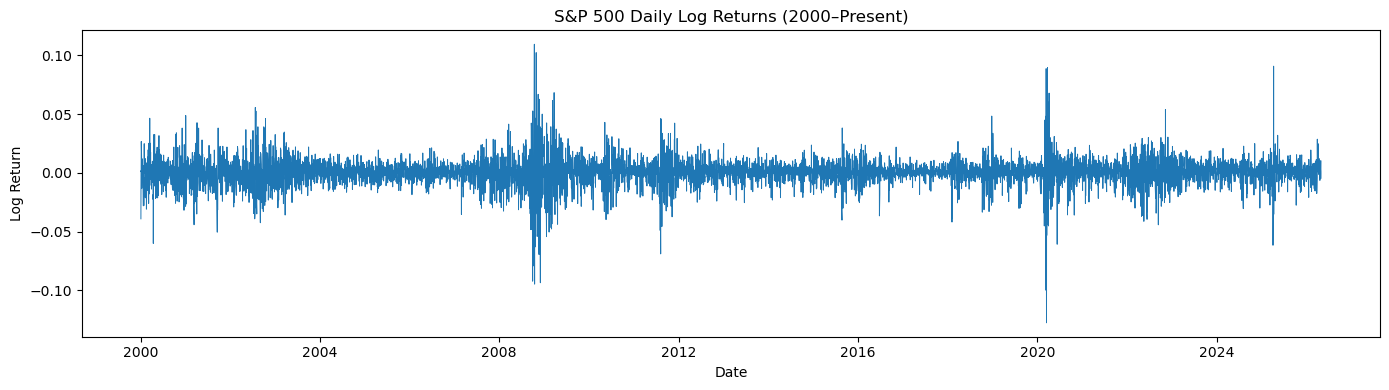

In [21]:
# Visualize log returns over time
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(raw.index, raw['log_returns'], linewidth=0.7)
plt.title('S&P 500 Daily Log Returns (2000–Present)')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.tight_layout()
plt.show()

In [33]:
# Visualize log returns over time
fig = raw['log_returns'].plot(title='S&P 500 Daily Log Returns (2000–Present)')
fig.update_layout(
    showlegend=False,
    yaxis_title='Log Return',
    xaxis_title='Date'
)
fig.show()

The Chart Confirms Volatility Clustering, Major spikes in returns on both ways on 
Financial Crisis 2008, during Covid crash on 2020 and slightly smaller spike on early 2026 
While period between 2013 and 2019 is lower volatility and stable time.